In [90]:
""" 
IMPORTS
"""
import os
import numpy as np
import pickle
import pandas as pd
from one.api import ONE
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from matplotlib.colors import ListedColormap
import seaborn as sns
from datetime import datetime
from pathlib import Path

one = ONE(mode='remote')

# Individual sessions

In [91]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/states_files/'
clustering_dir = prefix + 'clustering/'

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
trials_df = pd.read_parquet(prefix + '4_mice/session_trial_meta_03-07-2026')
print(f"LDA sessions: {lda['session'].nunique()}")

LDA sessions: 248


In [93]:
prefix + '4_mice/session_trial_meta_03-07-2026'

'/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/4_mice/session_trial_meta_03-07-2026'

In [70]:
states_df = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')
print(states_df.shape)
print(states_df.dtypes)
states_df.head()

(296090, 9)
animal              object
eid                 object
contrastLeft       float64
contrastRight      float64
rewarded           float64
probabilityLeft    float64
p_state1           float64
p_state2           float64
signed_contrast    float64
dtype: object


,animal,eid,contrastLeft,contrastRight,rewarded,probabilityLeft,p_state1,p_state2,signed_contrast
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,1.00,NaN,1.0,0.5,0.000021,0.999979,-1.000
1,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,NaN,0.125,-1.0,0.5,0.079605,0.920395,0.125
2,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,0.25,NaN,1.0,0.5,0.365950,0.634050,-0.250
3,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,NaN,1.000,1.0,0.5,0.557431,0.442569,1.000
4,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,0.00,NaN,1.0,0.5,0.600120,0.399880,0.000


In [71]:
print(f"Animals: {states_df['animal'].nunique()}, sessions (eid): {states_df['eid'].nunique()}, trials: {len(states_df)}")
print(f"Overlap with LDA sessions: {len(set(states_df['eid']) & set(lda['session']))} / {lda['session'].nunique()}")
print(f"Overlap with LDA mice: {len(set(states_df['animal']) & set(lda['mouse_name']))} / {lda['mouse_name'].nunique()}")
states_df[['p_state1', 'p_state2']].describe()

Animals: 139, sessions (eid): 459, trials: 296090
Overlap with LDA sessions: 244 / 248
Overlap with LDA mice: 56 / 56


,p_state1,p_state2
count,2.960900e+05,2.960900e+05
mean,7.899042e-01,2.100958e-01
std,2.975328e-01,2.975328e-01
min,1.000156e-18,2.859175e-11
25%,7.525475e-01,1.544382e-02
50%,9.321986e-01,6.780135e-02
75%,9.845562e-01,2.474525e-01
max,1.000000e+00,1.000000e+00


# GLM-HMM states for the LDA mice/sessions

In [72]:
# Per-session GLM-HMM state occupancy: mean trial-level state probabilities
session_states = states_df.groupby('eid').agg(
    animal=('animal', 'first'),
    n_trials=('eid', 'size'),
    mean_p_state1=('p_state1', 'mean'),
    mean_p_state2=('p_state2', 'mean'),
).reset_index().rename(columns={'eid': 'session'})

# dominant state = state with highest mean occupancy across the session's trials
session_states['dominant_state'] = session_states[['mean_p_state1', 'mean_p_state2']].idxmax(axis=1).str.replace('mean_p_', '')

lda_states = lda.merge(session_states.drop(columns='animal'), on='session', how='left')

n_matched = lda_states['mean_p_state1'].notna().sum()
print(f"LDA sessions with GLM-HMM states: {n_matched} / {len(lda_states)}")
lda_states[lda_states['mean_p_state1'].isna()][['mouse_name', 'session']]

LDA sessions with GLM-HMM states: 244 / 248


,mouse_name,session
14,UCLA048,169c9a39-cb63-4b77-93e2-10e076d4c472
40,UCLA052,3513e7f2-d2e6-4411-8055-54dac50458f6
130,UCLA048,80653a5b-c7aa-479d-9ae0-c92f296fface
190,UCLA052,d035c5ba-d51e-49a9-a94b-23531a598ec3


# Psychometric and chronometric curves per GLM-HMM state

State labels (`state1`/`state2`) are arbitrary outputs of the GLM-HMM fit — whether one corresponds to "engaged" and the other to "disengaged"/biased behavior is not yet known and is exactly what these curves are meant to reveal (steeper psychometric slope + lower lapse rate + faster, contrast-dependent RTs = more engaged).

In [73]:
# Per-trial choice_right, block and dominant state - derived entirely from states_df, no extra merge needed.
# choice_right definition matches engaged.py's plot_psychometric_curves exactly:
# contrastLeft is NaN => stimulus was on the right, so a rewarded trial means the animal went right;
# contrastRight is NaN => stimulus was on the left, so an unrewarded trial means the animal went right.
# This is well-defined even at 0% contrast, since the stimulus side (not just its magnitude) is always
# recorded as whichever of contrastLeft/contrastRight is non-null.
right_correct = states_df['contrastLeft'].isna() & (states_df['rewarded'] == 1)
right_incorrect = states_df['contrastRight'].isna() & (states_df['rewarded'] == -1)
states_df['choice_right'] = (right_correct | right_incorrect).astype(int)
states_df['block'] = states_df['probabilityLeft']
states_df['dominant_state'] = np.where(states_df['p_state1'] >= 0.5, 'state1', 'state2')

print(states_df['block'].value_counts())
print(states_df['dominant_state'].value_counts())
states_df[['eid', 'signed_contrast', 'block', 'rewarded', 'choice_right', 'p_state1', 'dominant_state']].head()

block
0.8    130533
0.2    124247
0.5     41310
Name: count, dtype: int64
dominant_state
state1    248189
state2     47901
Name: count, dtype: int64


,eid,signed_contrast,block,rewarded,choice_right,p_state1,dominant_state
0,034e726f-b35f-41e0-8d6c-a22cc32391fb,-1.000,0.5,1.0,0,0.000021,state2
1,034e726f-b35f-41e0-8d6c-a22cc32391fb,0.125,0.5,-1.0,0,0.079605,state2
2,034e726f-b35f-41e0-8d6c-a22cc32391fb,-0.250,0.5,1.0,0,0.365950,state2
3,034e726f-b35f-41e0-8d6c-a22cc32391fb,1.000,0.5,1.0,1,0.557431,state1
4,034e726f-b35f-41e0-8d6c-a22cc32391fb,0.000,0.5,1.0,0,0.600120,state1


In [74]:
from scipy.optimize import curve_fit

# Sigmoid-fit style follows psycho_chrono_curves.ipynb; choice_right derivation follows engaged.py's
# plot_psychometric_curves. Blocks include 0.5 (unbiased) alongside the two biased blocks, per session/state.
BLOCK_COLORS = {0.2: 'tab:blue', 0.5: 'tab:orange', 0.8: 'tab:green'}
STATES = ['state1', 'state2']


def sigmoid(x, mu, sigma, gamma, lambda_):
    """Psychometric function: mu=bias, sigma=slope, gamma/lambda_=lower/upper lapse."""
    return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


def plot_psychometric(ax, data, title):
    for block, color in BLOCK_COLORS.items():
        block_data = data[data['block'] == block]
        if block_data.empty:
            continue
        summary = block_data.groupby('signed_contrast')['choice_right'].mean().reset_index()
        ax.scatter(summary['signed_contrast'] * 100, summary['choice_right'], color=color, alpha=0.6, s=25)
        try:
            popt, _ = curve_fit(
                sigmoid, block_data['signed_contrast'] * 100, block_data['choice_right'],
                p0=[0, 10, 0.05, 0.05], bounds=([-100, 0.1, 0, 0], [100, 100, 0.4, 0.4]),
            )
            x_range = np.linspace(-100, 100, 100)
            ax.plot(x_range, sigmoid(x_range, *popt), color=color, label=f'Block {block}')
        except Exception:
            ax.plot(summary['signed_contrast'] * 100, summary['choice_right'], color=color, alpha=0.4)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)
    ax.set_xlabel('Signed contrast (%)')
    ax.set_ylabel('P(choice = right)')


def plot_chronometric(ax, data, title):
    for block, color in BLOCK_COLORS.items():
        block_data = data[data['block'] == block].dropna(subset=['reaction_time'])
        if block_data.empty:
            continue
        summary = block_data.groupby('signed_contrast')['reaction_time'].agg(['mean', 'sem']).reset_index()
        ax.errorbar(summary['signed_contrast'] * 100, summary['mean'], yerr=summary['sem'],
                     fmt='o-', color=color, markersize=4, capsize=3, alpha=0.8, label=f'Block {block}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Signed contrast (%)')
    ax.set_ylabel('Mean reaction time (s)')


def plot_session_state_curves(eid, trial_df):
    """trial_df: per-trial rows for one session with signed_contrast, block, choice_right,
    reaction_time and dominant_state columns. Chronometric row shares a y-axis across states
    so RT levels are directly comparable between state1 and state2."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey='row')
    for col, state in enumerate(STATES):
        state_data = trial_df[trial_df['dominant_state'] == state]
        n = len(state_data)
        plot_psychometric(axes[0, col], state_data, f'{state} (n={n} trials) - psychometric')
        plot_chronometric(axes[1, col], state_data, f'{state} - chronometric')
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f'eid: {eid}')
    plt.tight_layout()
    return fig

In [86]:
# Demo set: mix of sessions with substantial state2 occupancy and "typical" mostly-state1 sessions,
# restricted to sessions that are both in LDA and have GLM-HMM states.
matched = lda_states.dropna(subset=['mean_p_state1'])
high_state2 = matched.sort_values('mean_p_state2', ascending=False).head(10)['session'].tolist()
low_state2 = matched.sort_values('mean_p_state2', ascending=True).head(10)['session'].tolist()
demo_eids = high_state2 + low_state2
print('High state2 occupancy demo sessions:', high_state2)
print('Low state2 occupancy (typical) demo sessions:', low_state2)


def fetch_reaction_time(eid):
    """firstMovement_times - stimOn_times, aligned 1:1 with states_df rows for this eid.
    No RT is cached anywhere locally (engaged.py's 'all_trials_with_engagement.pqt' from
    Alberto isn't present on this machine), so it's fetched live via ONE; row order was
    validated to match the raw ONE trials object exactly (feedbackType/contrasts checked)."""
    trials = one.load_object(eid, 'trials', collection='alf')
    rt = trials['firstMovement_times'] - trials['stimOn_times']
    return rt

High state2 occupancy demo sessions: ['d71e565d-4ddb-42df-849e-f99cfdeced52', '111c1762-7908-47e0-9f40-2f2ee55b6505', 'd7e60cc3-6020-429e-a654-636c6cc677ea', '61caa69d-088b-465a-b9d0-d75341dabac6', '5455a21c-1be7-4cae-ae8e-8853a8d5f55e', '6668c4a0-70a4-4012-a7da-709660971d7a', '3537d970-f515-4786-853f-23de525e110f', 'bb6a5aae-2431-401d-8f6a-9fdd6de655a9', 'ab8a0899-a59f-42e4-8807-95b14056104b', 'f5591ac5-311d-4fa8-9bad-029d7be9c491']
Low state2 occupancy (typical) demo sessions: ['1b61b7f2-a599-4e40-abd6-3e758d2c9e25', '931a70ae-90ee-448e-bedb-9d41f3eda647', 'eacc49a9-f3a1-49f1-b87f-0972f90ee837', '51e53aff-1d5d-4182-a684-aba783d50ae5', '537677fe-1e24-4755-948c-fa4a4e8ecce5', '687017d4-c9fc-458f-a7d5-0979fe1a7470', 'eef82e27-c20e-48da-b4b7-c443031649e3', '12dc8b34-b18e-4cdd-90a9-da134a9be79c', '5bcafa14-71cb-42fa-8265-ce5cda1b89e0', '2e6e179c-fccc-4e8f-9448-ce5b6858a183']


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


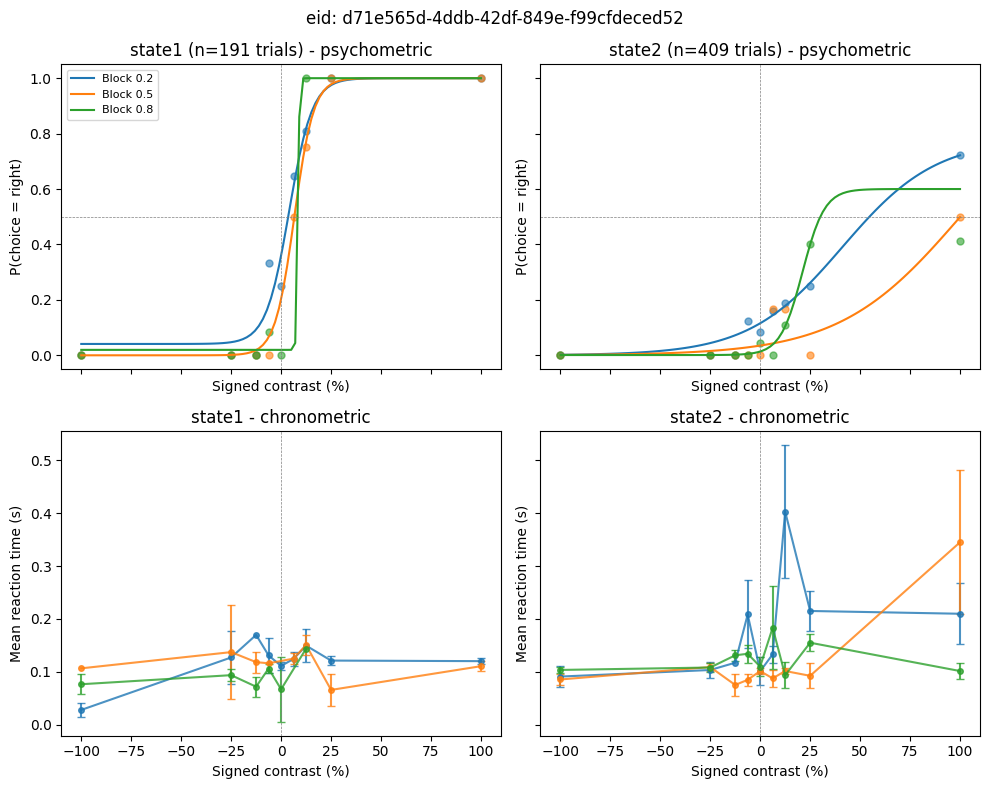

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_60073/2564047933.py:11: RuntimeWarning: overflow encountered in exp
  return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


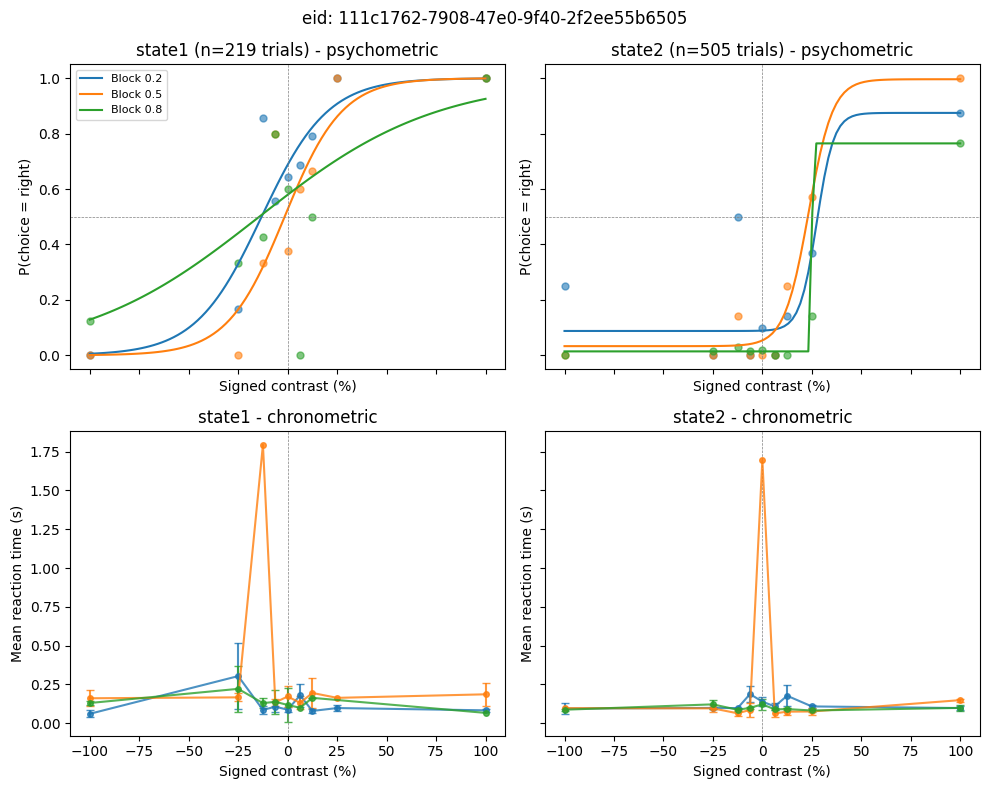

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_60073/2564047933.py:11: RuntimeWarning: overflow encountered in exp
  return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


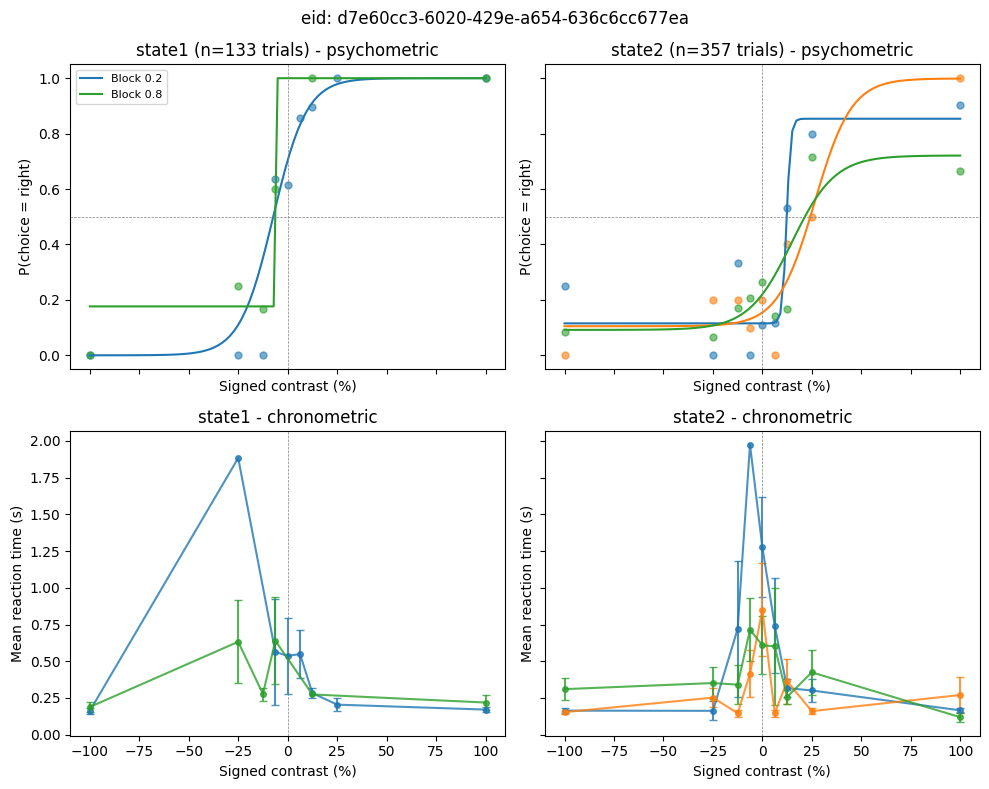

Skipping 61caa69d-088b-465a-b9d0-d75341dabac6: could not fetch trials (Extra data: line 1 column 235560 (char 235559))


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


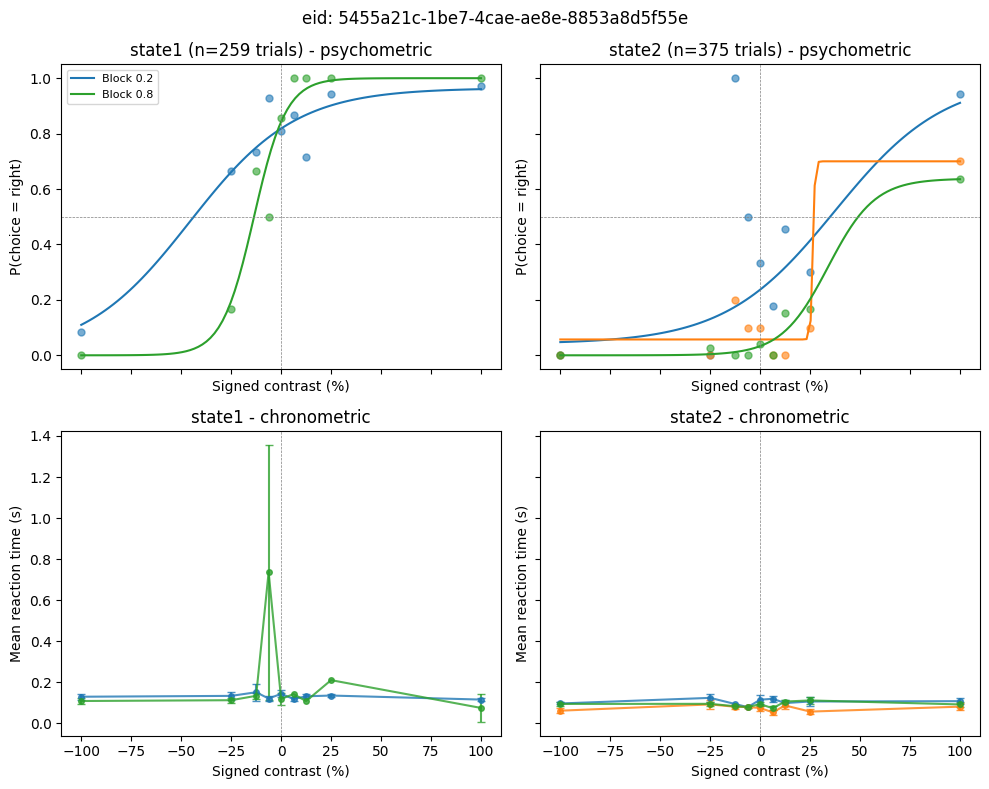

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


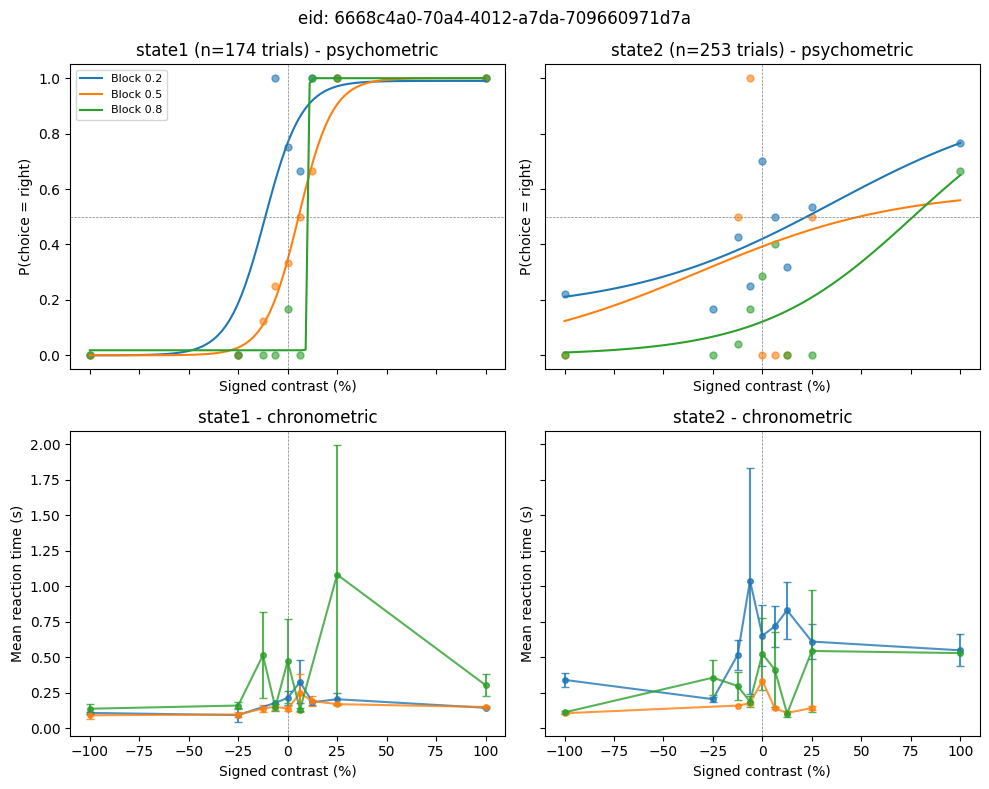

Skipping 3537d970-f515-4786-853f-23de525e110f: could not fetch trials (Extra data: line 1 column 254164 (char 254163))


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_60073/2564047933.py:11: RuntimeWarning: overflow encountered in exp
  return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


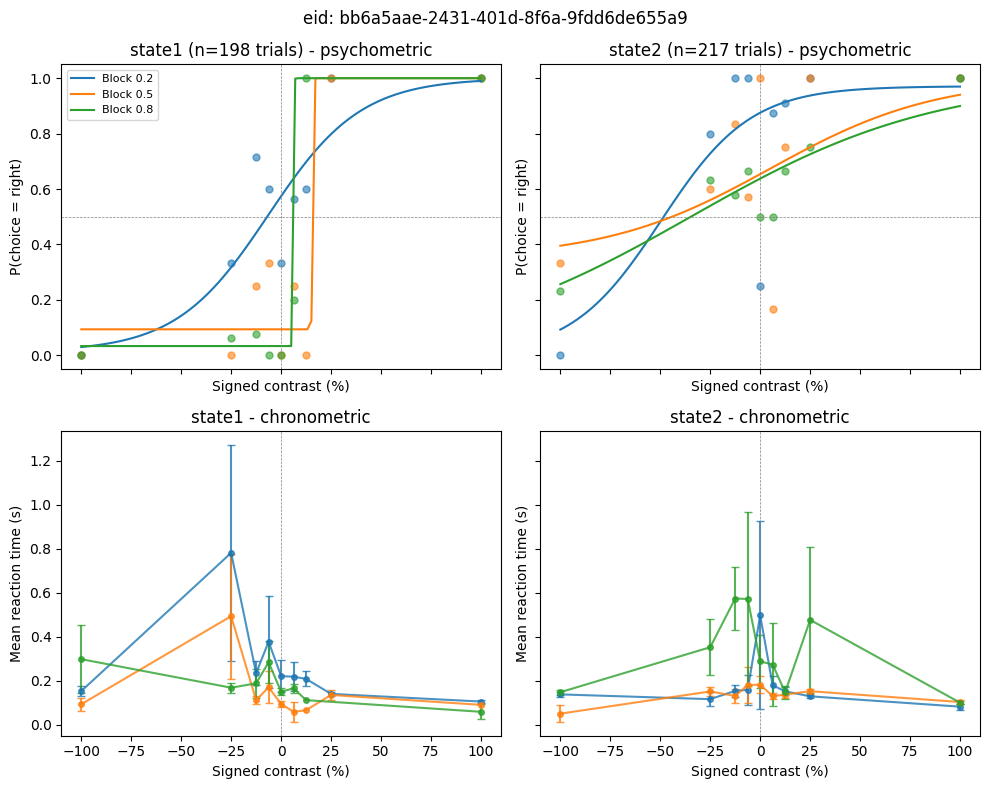

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


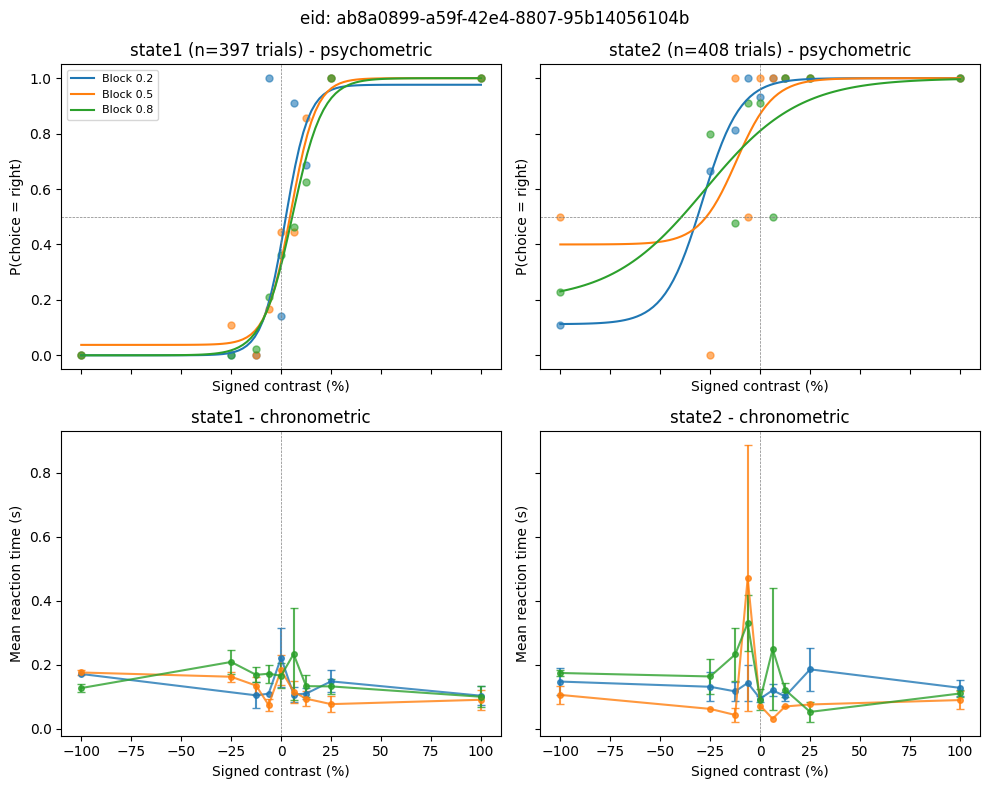

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


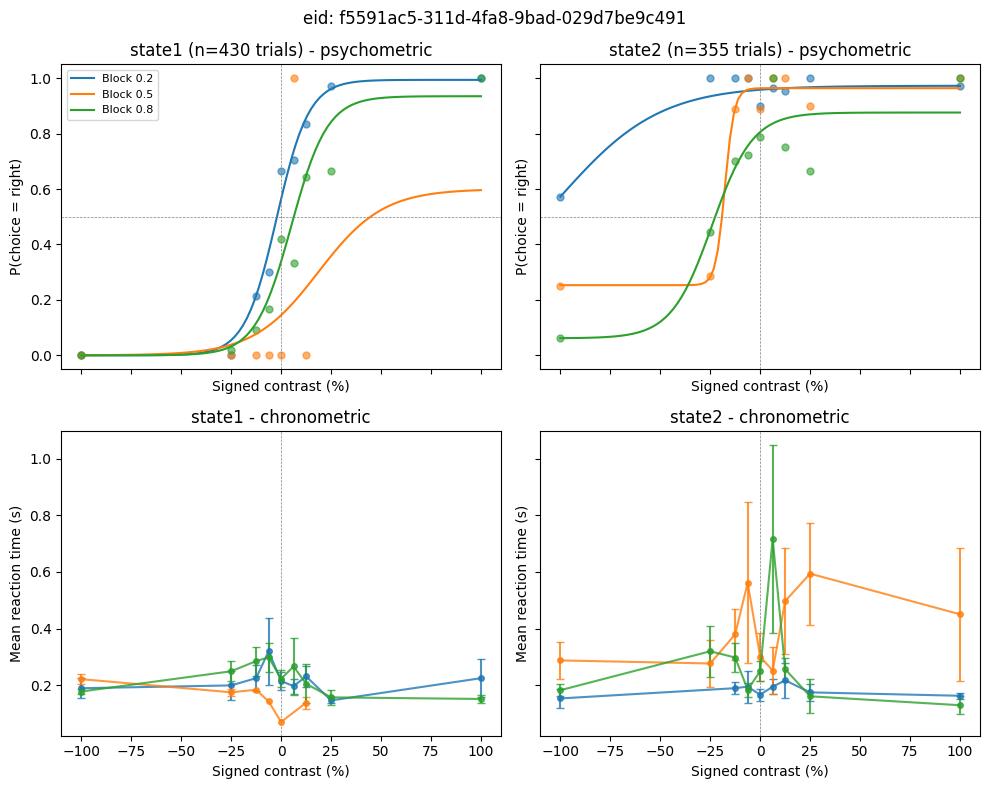

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


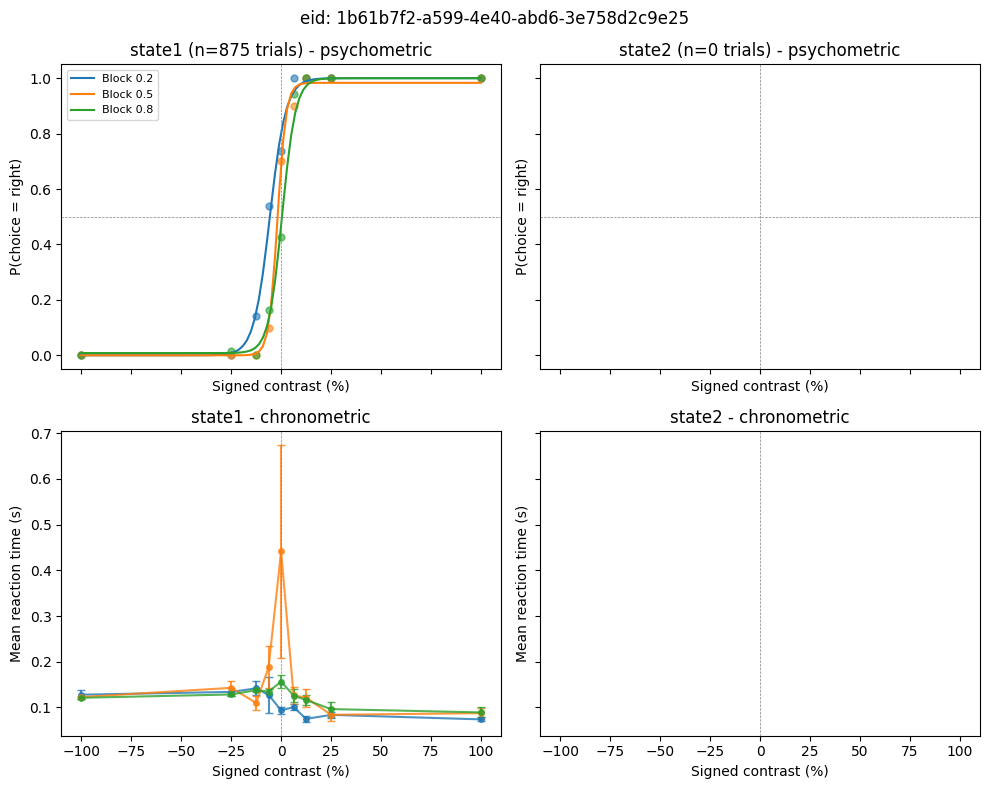

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


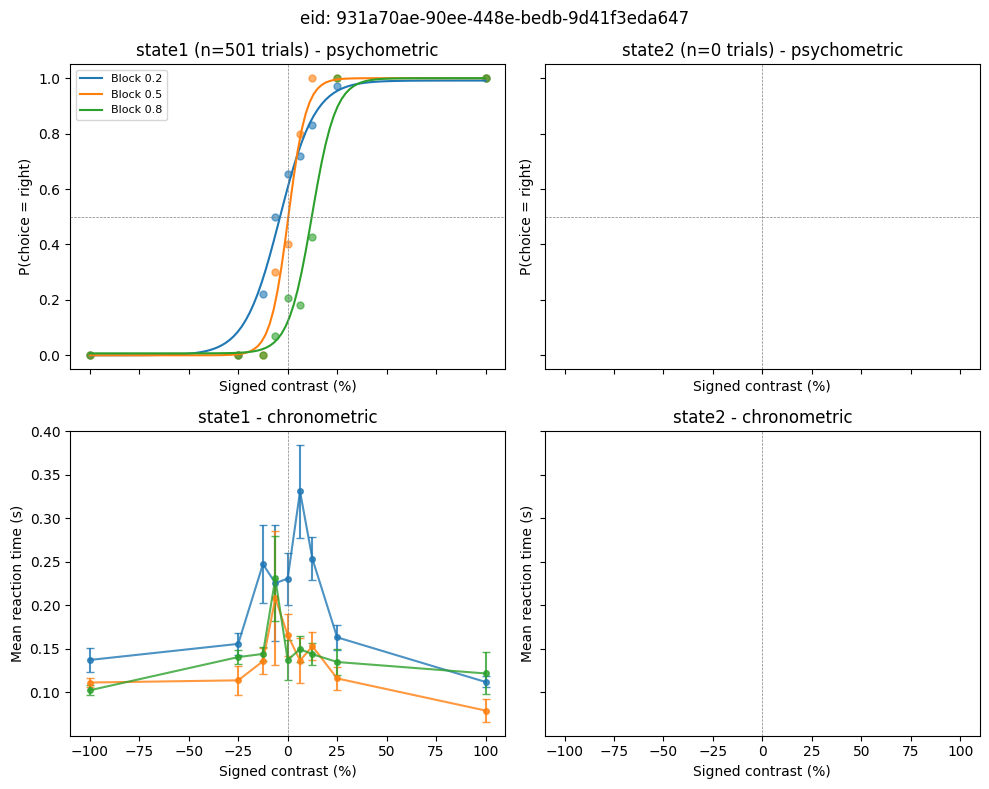

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


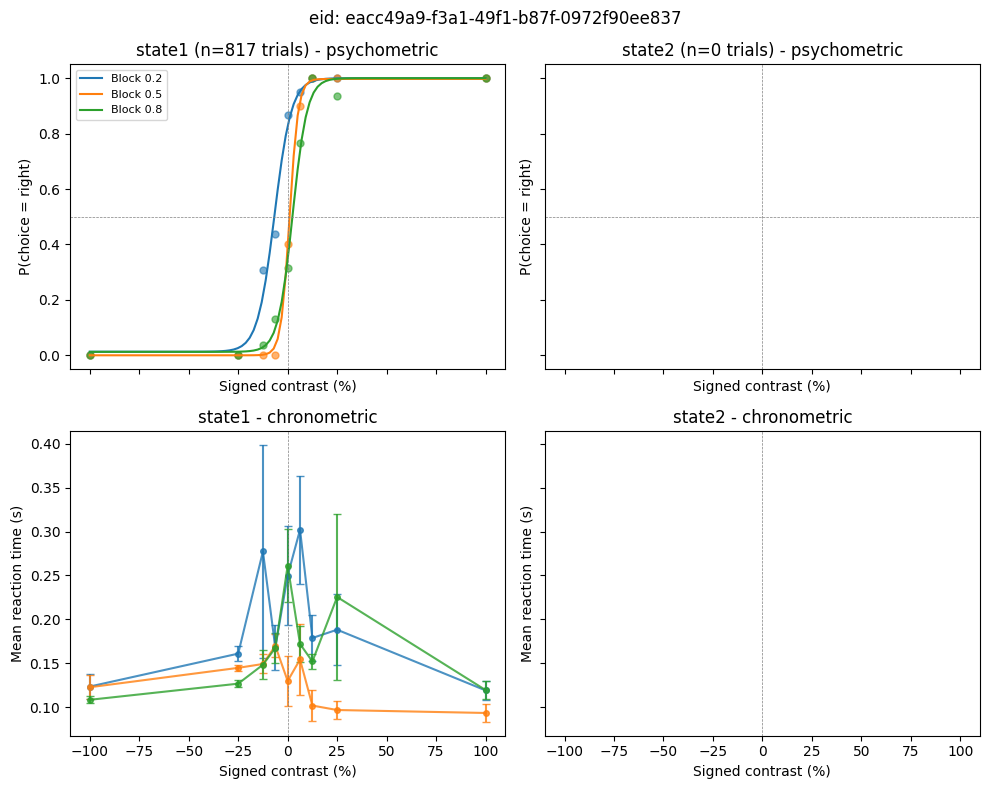

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


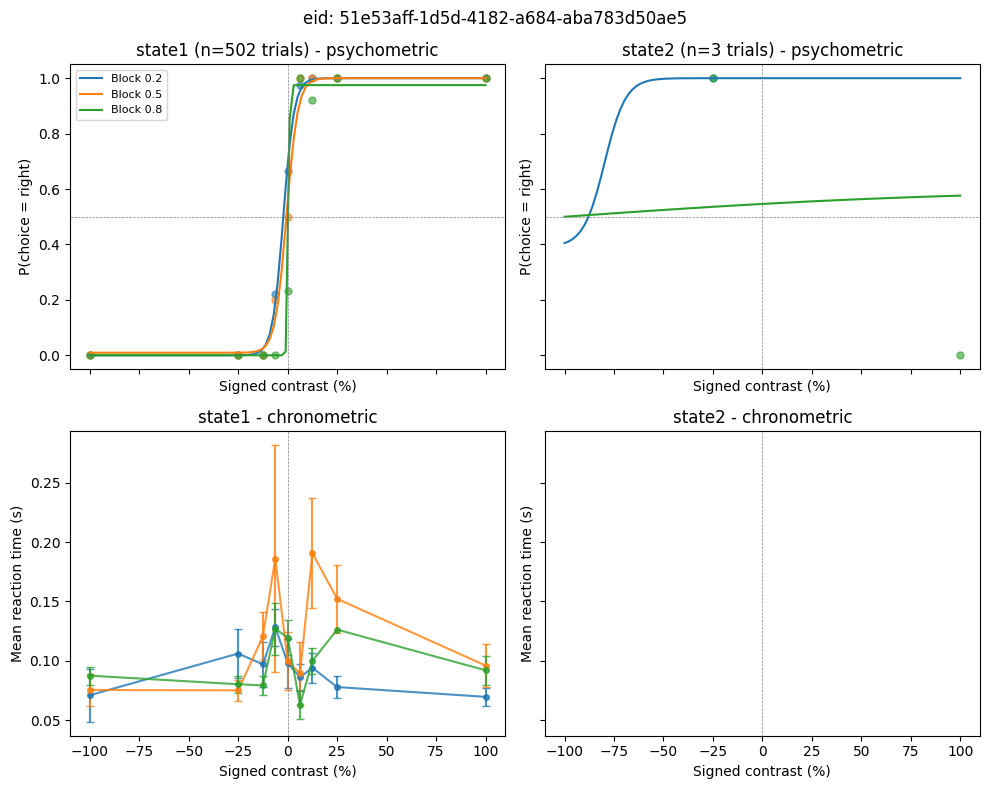

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_60073/2564047933.py:11: RuntimeWarning: overflow encountered in exp
  return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


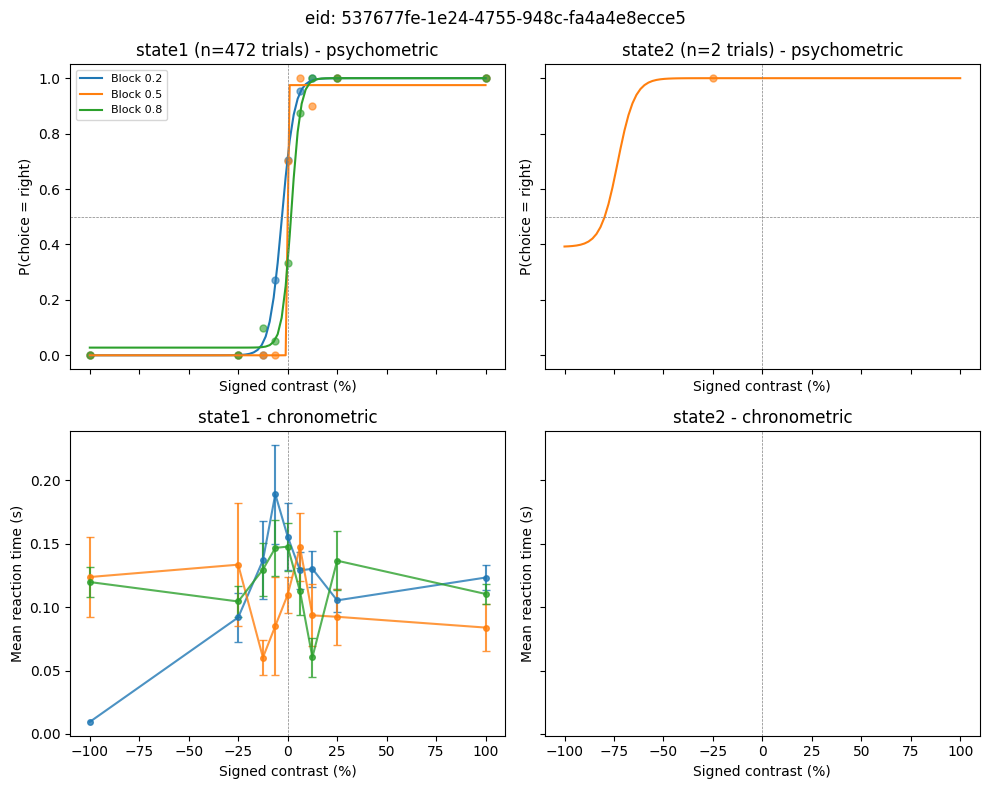

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


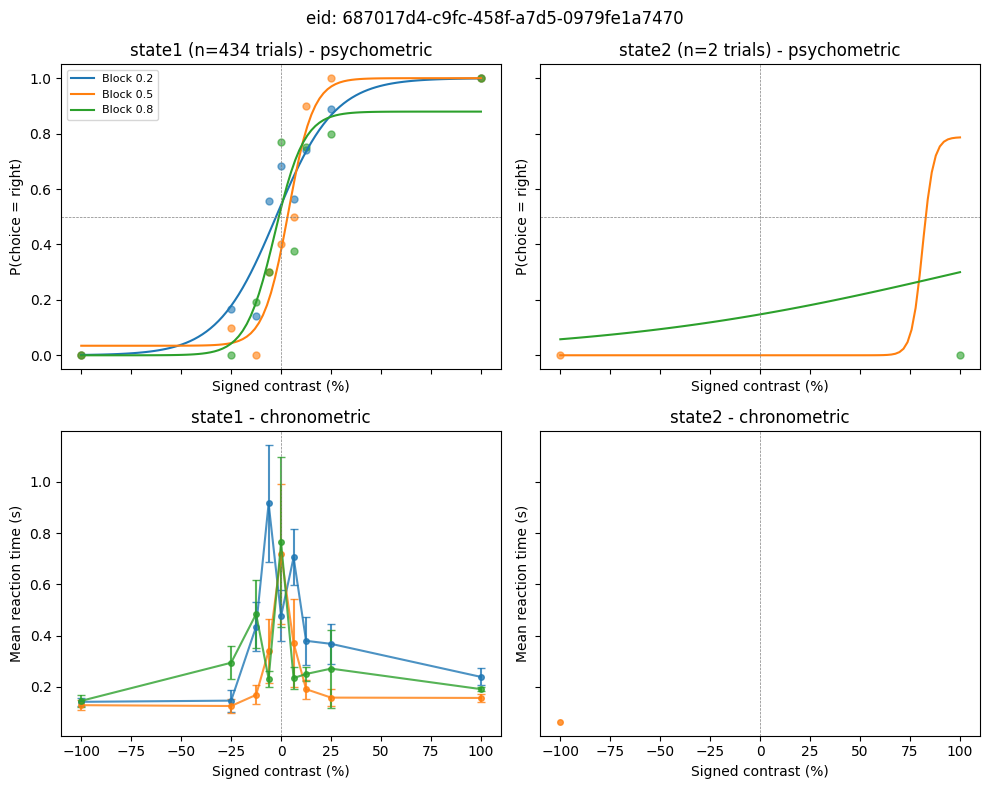

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


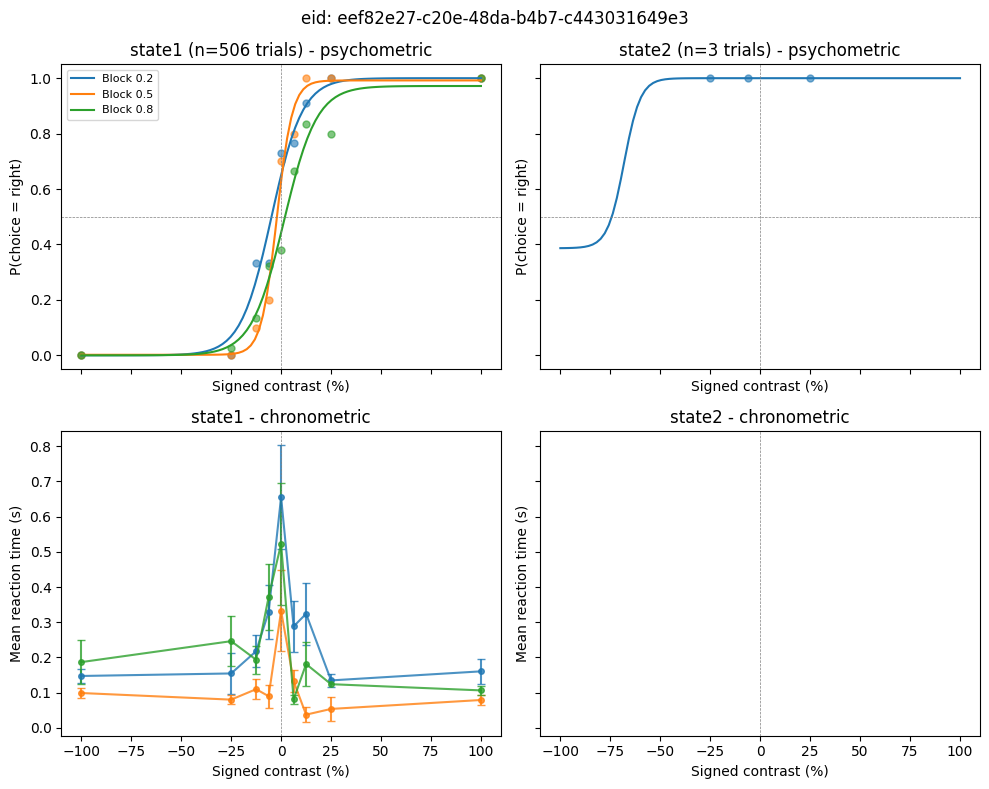

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


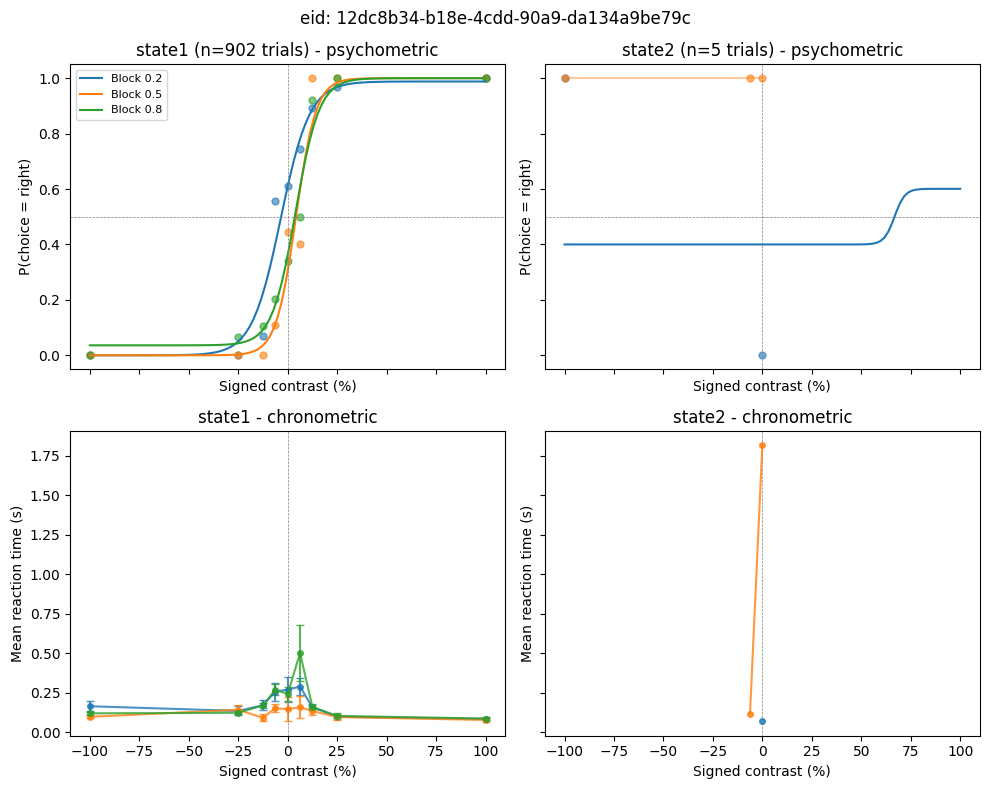

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_60073/2564047933.py:11: RuntimeWarning: overflow encountered in exp
  return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covarianc

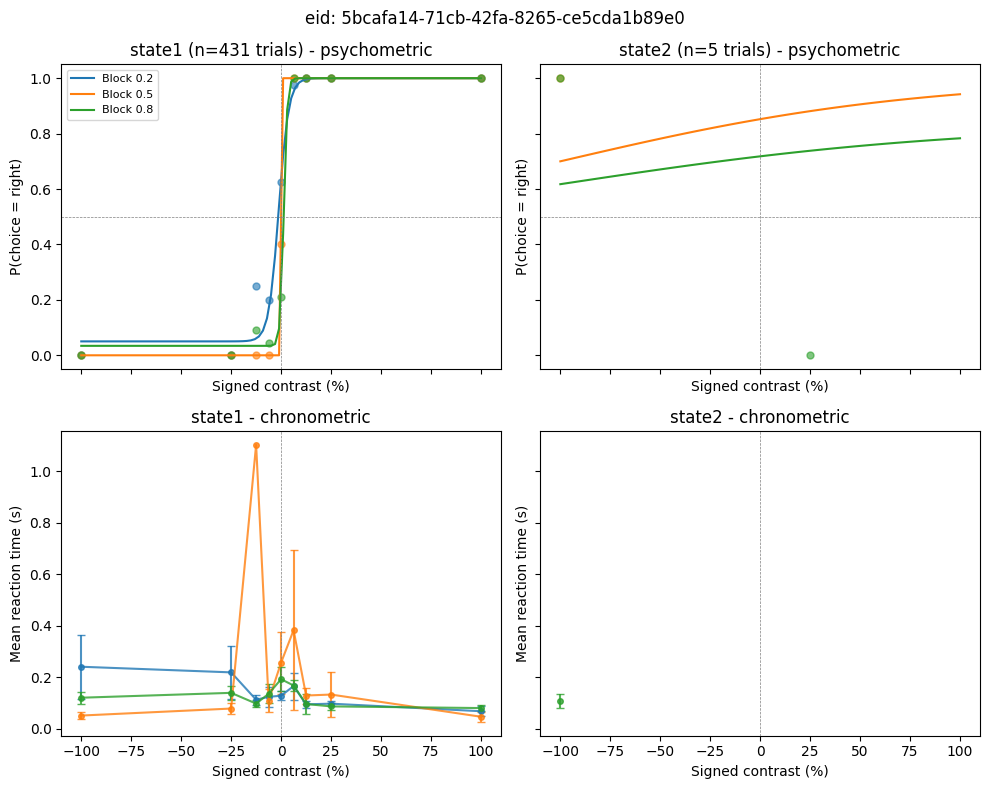

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


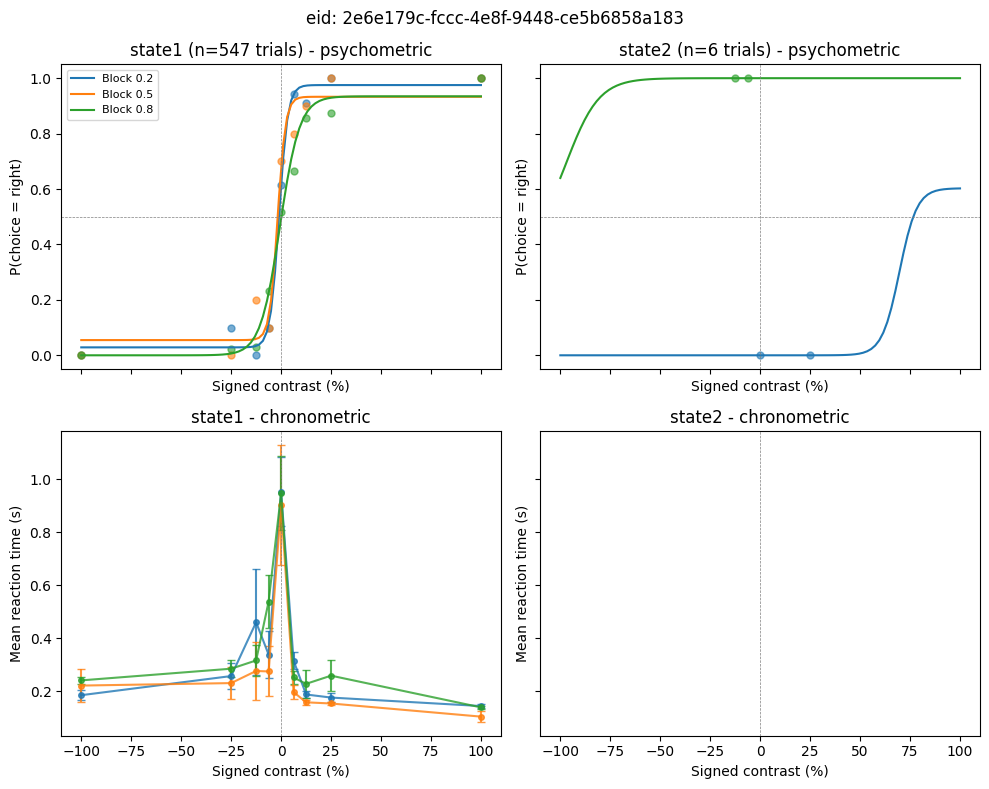

In [87]:
for eid in demo_eids:
    session_data = states_df[states_df['eid'] == eid].reset_index(drop=True)

    try:
        rt = fetch_reaction_time(eid)
    except Exception as e:
        print(f"Skipping {eid}: could not fetch trials ({e})")
        continue

    if len(rt) != len(session_data):
        print(f"Skipping {eid}: trial count mismatch (ONE={len(rt)} vs states_df={len(session_data)})")
        continue

    session_data['reaction_time'] = rt
    # standard IBL RT inclusion window (movement before stim onset or >2s excluded as non-decision trials)
    session_data.loc[(session_data['reaction_time'] < 0) | (session_data['reaction_time'] > 2), 'reaction_time'] = np.nan

    plot_session_state_curves(eid, session_data)
    plt.show()

# Ratio of GLM-HMM states across sessions

Per-session `state_ratio = mean_p_state2 / mean_p_state1` (states sum to 1, so this is equivalent to the state2:state1 occupancy odds). Computed over the 244 LDA-matched sessions from `lda_states`.

count    244.000000
mean       0.283347
std        0.316408
min        0.009231
25%        0.114342
50%        0.202748
75%        0.332208
max        2.314191
Name: state_ratio, dtype: float64

count    244.000000
mean       0.191910
std        0.126233
min        0.009147
25%        0.102609
50%        0.168570
75%        0.249367
max        0.698267
Name: mean_p_state2, dtype: float64


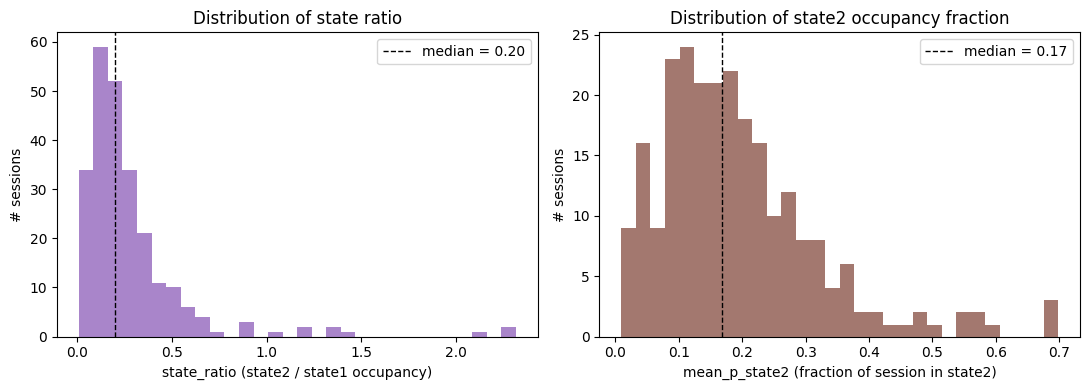

In [88]:
matched = matched.copy()
matched['state_ratio'] = matched['mean_p_state2'] / matched['mean_p_state1']

print(matched['state_ratio'].describe())
print()
print(matched['mean_p_state2'].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(matched['state_ratio'], bins=30, color='tab:purple', alpha=0.8)
axes[0].axvline(matched['state_ratio'].median(), color='k', linestyle='--', linewidth=1,
                 label=f"median = {matched['state_ratio'].median():.2f}")
axes[0].set_xlabel('state_ratio (state2 / state1 occupancy)')
axes[0].set_ylabel('# sessions')
axes[0].set_title('Distribution of state ratio')
axes[0].legend()

axes[1].hist(matched['mean_p_state2'], bins=30, color='tab:brown', alpha=0.8)
axes[1].axvline(matched['mean_p_state2'].median(), color='k', linestyle='--', linewidth=1,
                 label=f"median = {matched['mean_p_state2'].median():.2f}")
axes[1].set_xlabel('mean_p_state2 (fraction of session in state2)')
axes[1].set_ylabel('# sessions')
axes[1].set_title('Distribution of state2 occupancy fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation between state ratio and LDA 1

Pearson (lda_1 vs log(state_ratio)):  r = -0.189, p = 0.0030
Spearman (lda_1 vs state_ratio):      r = -0.172, p = 0.0072


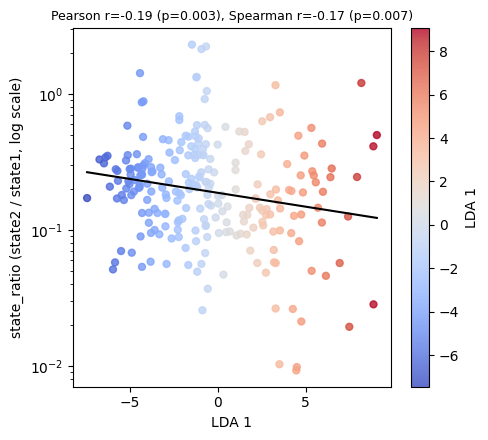

In [78]:
from scipy.stats import pearsonr, spearmanr

# state_ratio is a positive, right-skewed ratio, so Pearson is computed on log(state_ratio)
# (Spearman is rank-based and invariant to the log transform either way).
log_ratio = np.log(matched['state_ratio'])
r_pearson, p_pearson = pearsonr(matched['lda_1'], log_ratio)
r_spearman, p_spearman = spearmanr(matched['lda_1'], matched['state_ratio'])

print(f"Pearson (lda_1 vs log(state_ratio)):  r = {r_pearson:.3f}, p = {p_pearson:.4f}")
print(f"Spearman (lda_1 vs state_ratio):      r = {r_spearman:.3f}, p = {p_spearman:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(matched['lda_1'], matched['state_ratio'], c=matched['lda_1'], cmap='coolwarm', alpha=0.8, s=25)
ax.set_yscale('log')

# log-linear fit for display: state_ratio = exp(a * lda_1 + b)
a, b = np.polyfit(matched['lda_1'], log_ratio, 1)
x_range = np.linspace(matched['lda_1'].min(), matched['lda_1'].max(), 100)
ax.plot(x_range, np.exp(a * x_range + b), color='k', linewidth=1.5)

ax.set_xlabel('LDA 1')
ax.set_ylabel('state_ratio (state2 / state1, log scale)')
ax.set_title(f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), Spearman r={r_spearman:.2f} (p={p_spearman:.3f})",
             fontsize=9)
fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()

# State transitions across trials within a session

`p_state1` over trial number, looping through `demo_eids`. Background shading marks the bias block (0.2/0.5/0.8) each trial belonged to, using the same colors as the psychometric/chronometric plots.

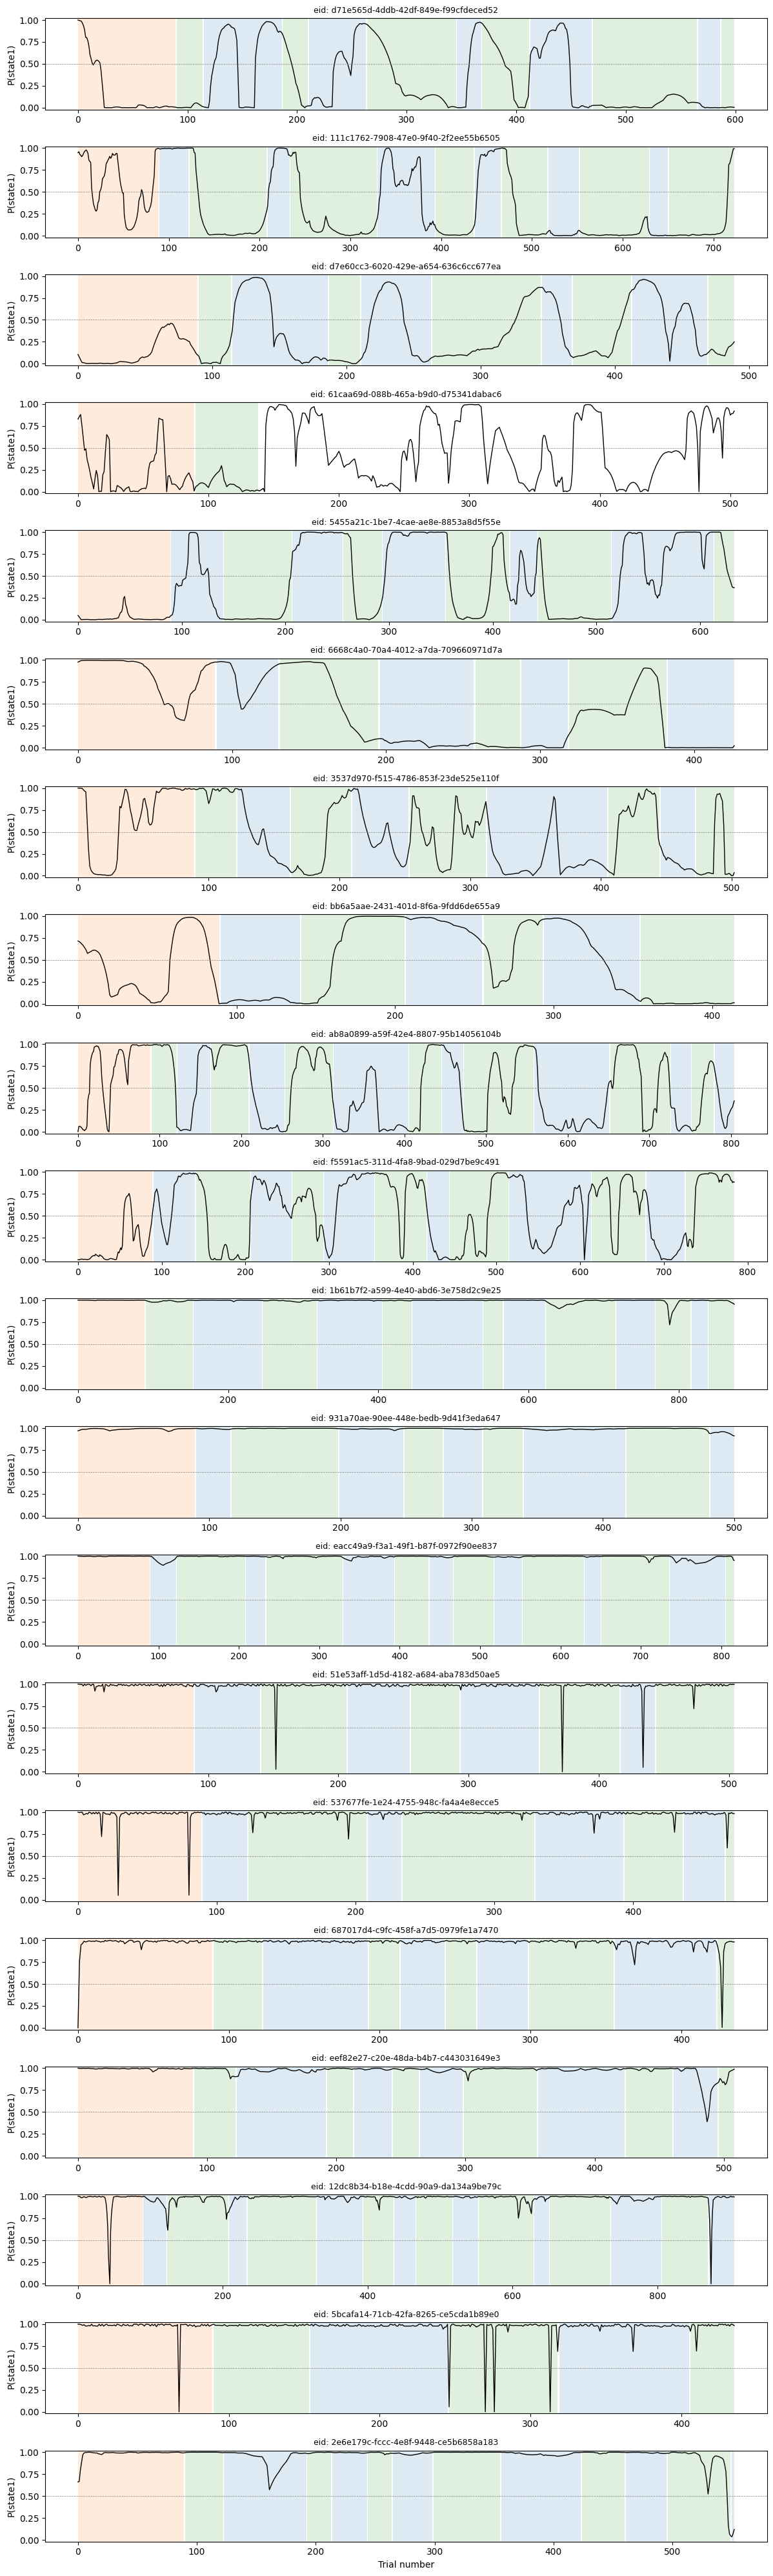

In [89]:
def plot_state_trace(ax, trial_df, title):
    trial_df = trial_df.reset_index(drop=True)
    block_vals = trial_df['block'].values
    x = np.arange(len(trial_df))

    # shade contiguous block runs
    change_idx = np.where(np.diff(block_vals) != 0)[0] + 1
    seg_starts = np.concatenate([[0], change_idx])
    seg_ends = np.concatenate([change_idx, [len(block_vals)]])
    for s, e in zip(seg_starts, seg_ends):
        ax.axvspan(s, e - 1, color=BLOCK_COLORS[block_vals[s]], alpha=0.15, linewidth=0)

    ax.plot(x, trial_df['p_state1'], color='k', linewidth=1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('P(state1)')
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(demo_eids), 1, figsize=(12, 2 * len(demo_eids)))
for ax, eid in zip(axes, demo_eids):
    session_data = states_df[states_df['eid'] == eid]
    plot_state_trace(ax, session_data, f'eid: {eid}')
axes[-1].set_xlabel('Trial number')
plt.tight_layout()
plt.show()

# Empirical state transition matrix per session

Empirical (not fitted) trial-to-trial transition probabilities `P(state_{t+1} | state_t)` from the dominant-state sequence, looped over `demo_eids`, plus the pooled matrix across all 244 LDA-matched sessions for context. Heatmap style follows `engaged.py`'s `plot_model_params`.

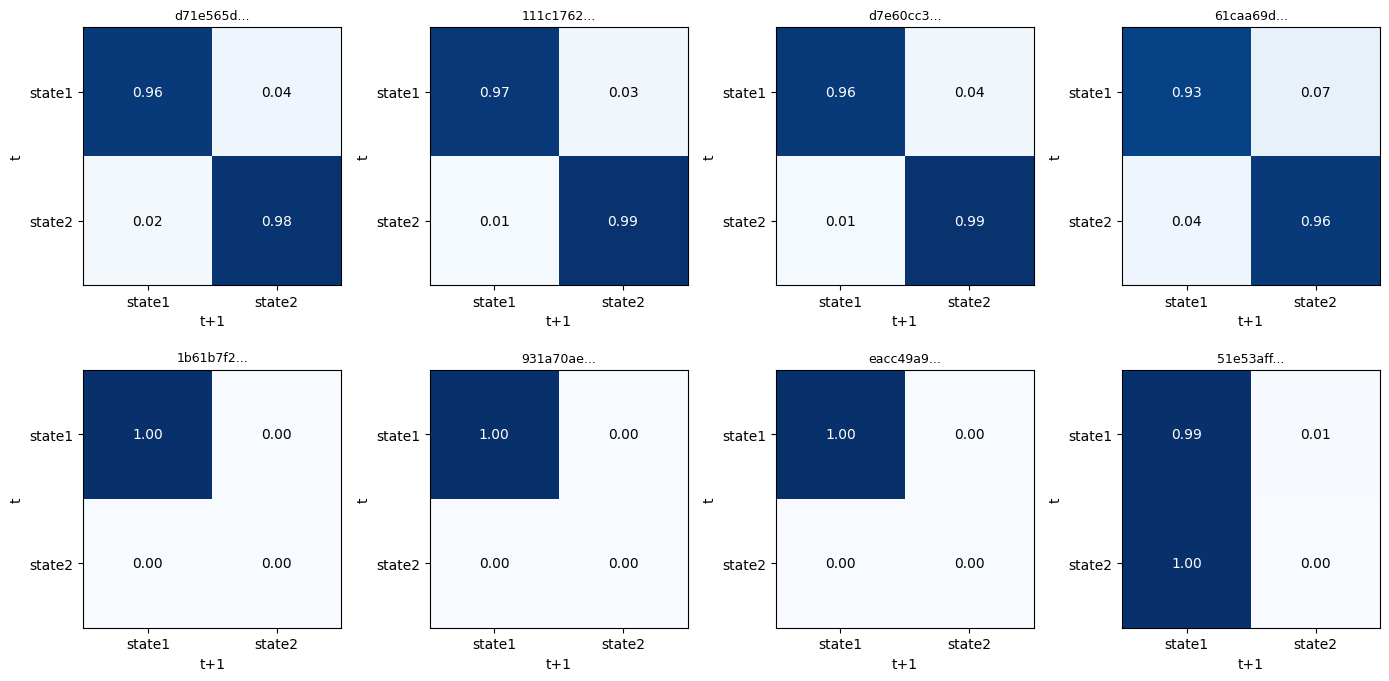

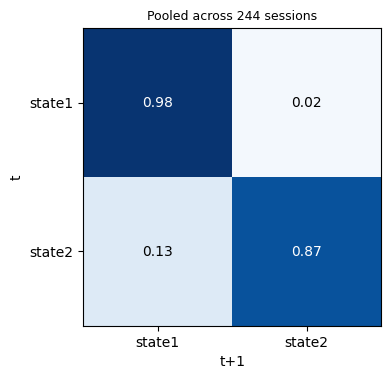

Expected dwell time: state1 = 51.8 trials, state2 = 7.6 trials


In [80]:
def transition_counts(trial_df):
    """Raw trial-to-trial transition counts between dominant states, within one session."""
    state_seq = (trial_df['dominant_state'].values == 'state2').astype(int)
    counts = np.zeros((2, 2))
    np.add.at(counts, (state_seq[:-1], state_seq[1:]), 1)
    return counts


def normalize_rows(counts):
    row_sums = counts.sum(axis=1, keepdims=True)
    return np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)


def plot_transition_matrix(ax, trans_mat, title):
    ax.imshow(trans_mat, vmin=0, vmax=1, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{trans_mat[i, j]:.2f}', ha='center', va='center',
                    color='white' if trans_mat[i, j] > 0.5 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['state1', 'state2'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['state1', 'state2'])
    ax.set_xlabel('t+1'); ax.set_ylabel('t')
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, eid in zip(axes.flat, demo_eids):
    session_data = states_df[states_df['eid'] == eid]
    trans_mat = normalize_rows(transition_counts(session_data))
    plot_transition_matrix(ax, trans_mat, eid[:8] + '...')
plt.tight_layout()
plt.show()

# Pooled matrix across all LDA-matched sessions: sum raw counts within each session first so
# transitions never leak across a session boundary, then normalize once at the end.
pooled_counts = np.zeros((2, 2))
for eid in matched['session']:
    pooled_counts += transition_counts(states_df[states_df['eid'] == eid])
pooled_trans_mat = normalize_rows(pooled_counts)

fig, ax = plt.subplots(figsize=(4, 4))
plot_transition_matrix(ax, pooled_trans_mat, f'Pooled across {matched["session"].nunique()} sessions')
plt.tight_layout()
plt.show()

expected_dwell = 1 / (1 - np.diag(pooled_trans_mat))
print(f"Expected dwell time: state1 = {expected_dwell[0]:.1f} trials, state2 = {expected_dwell[1]:.1f} trials")

# State stickiness vs LDA 1

Per-session stickiness = mean of the transition matrix diagonal (`P(state1->state1)`, `P(state2->state2)`), i.e. how self-persistent the states are within that session. Sessions where a state never occurs have that diagonal entry left undefined (NaN) rather than 0, since "P(stay in a state that never happened)" isn't a meaningful 0.

Sessions where state2 never occurs (p22 undefined): 3 / 244
count    244.000000
mean       0.979980
std        0.014402
min        0.927374
25%        0.970431
50%        0.983838
75%        0.991251
max        1.000000
Name: stickiness, dtype: float64
Pearson (lda_1 vs stickiness):  r = 0.308, p = 0.0000
Spearman (lda_1 vs stickiness): r = 0.332, p = 0.0000


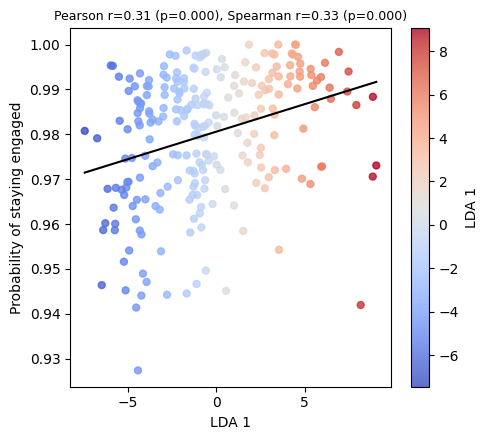

In [81]:
def session_diag(eid):
    counts = transition_counts(states_df[states_df['eid'] == eid])
    row_sums = counts.sum(axis=1)
    trans_mat = normalize_rows(counts)
    diag = np.diag(trans_mat).copy()
    diag[row_sums == 0] = np.nan
    return diag


diags = np.array([session_diag(eid) for eid in matched['session']])
matched['p11'] = diags[:, 0]
matched['p22'] = diags[:, 1]
matched['stickiness'] = np.nanmean(diags, axis=1)
matched['stickiness'] = matched['p11']

n_no_state2 = matched['p22'].isna().sum()
print(f"Sessions where state2 never occurs (p22 undefined): {n_no_state2} / {len(matched)}")
print(matched['stickiness'].describe())

r_pearson, p_pearson = pearsonr(matched['lda_1'], matched['stickiness'])
r_spearman, p_spearman = spearmanr(matched['lda_1'], matched['stickiness'])
print(f"Pearson (lda_1 vs stickiness):  r = {r_pearson:.3f}, p = {p_pearson:.4f}")
print(f"Spearman (lda_1 vs stickiness): r = {r_spearman:.3f}, p = {p_spearman:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(matched['lda_1'], matched['stickiness'], c=matched['lda_1'], cmap='coolwarm', alpha=0.8, s=25)

a, b = np.polyfit(matched['lda_1'], matched['stickiness'], 1)
x_range = np.linspace(matched['lda_1'].min(), matched['lda_1'].max(), 100)
ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)

ax.set_xlabel('LDA 1')
ax.set_ylabel('Probability of staying engaged')
ax.set_title(f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), Spearman r={r_spearman:.2f} (p={p_spearman:.3f})",
             fontsize=9)
fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()

# Mouse-averaged stickiness vs LDA 1

Same relationship as above, but each dot is one mouse: mean (± SEM) of `stickiness` and `lda_1` across that mouse's sessions, error bars in both directions. This removes pseudo-replication from mice contributing many sessions.

n = 56 mice
Pearson (lda_1 vs stickiness):  r = 0.416, p = 0.0014
Spearman (lda_1 vs stickiness): r = 0.440, p = 0.0007


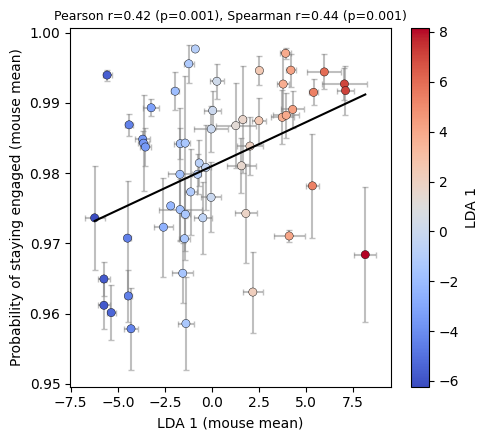

In [82]:
mouse_agg = matched.groupby('mouse_name').agg(
    lda1_mean=('lda_1', 'mean'),
    lda1_sem=('lda_1', 'sem'),
    stickiness_mean=('stickiness', 'mean'),
    stickiness_sem=('stickiness', 'sem'),
    n_sessions=('lda_1', 'size'),
).reset_index()
# single-session mice have an undefined SEM, not a zero-width error bar
mouse_agg[['lda1_sem', 'stickiness_sem']] = mouse_agg[['lda1_sem', 'stickiness_sem']].fillna(0)

r_pearson, p_pearson = pearsonr(mouse_agg['lda1_mean'], mouse_agg['stickiness_mean'])
r_spearman, p_spearman = spearmanr(mouse_agg['lda1_mean'], mouse_agg['stickiness_mean'])
print(f"n = {len(mouse_agg)} mice")
print(f"Pearson (lda_1 vs stickiness):  r = {r_pearson:.3f}, p = {p_pearson:.4f}")
print(f"Spearman (lda_1 vs stickiness): r = {r_spearman:.3f}, p = {p_spearman:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.errorbar(mouse_agg['lda1_mean'], mouse_agg['stickiness_mean'],
            xerr=mouse_agg['lda1_sem'], yerr=mouse_agg['stickiness_sem'],
            fmt='none', ecolor='gray', alpha=0.5, capsize=2, zorder=1)
sc = ax.scatter(mouse_agg['lda1_mean'], mouse_agg['stickiness_mean'], c=mouse_agg['lda1_mean'],
                 cmap='coolwarm', s=35, zorder=2, edgecolor='k', linewidth=0.3)

a, b = np.polyfit(mouse_agg['lda1_mean'], mouse_agg['stickiness_mean'], 1)
x_range = np.linspace(mouse_agg['lda1_mean'].min(), mouse_agg['lda1_mean'].max(), 100)
ax.plot(x_range, a * x_range + b, color='k', linewidth=1.5)

ax.set_xlabel('LDA 1 (mouse mean)')
ax.set_ylabel('Probability of staying engaged (mouse mean)')
ax.set_title(f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), Spearman r={r_spearman:.2f} (p={p_spearman:.3f})",
             fontsize=9)
fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()

# Empirical state-time ratio (trial counts, state1 as numerator)

Unlike `state_ratio` above (soft occupancy from averaged `p_state2`/`p_state1`), this uses the hard dominant-state trial counts directly: `state_time_ratio = n_trials(state1) / n_trials(state2)`. State1 is kept as the numerator as requested; since some sessions are entirely in state1 (`n_trials(state2) == 0`), this ratio is `inf` for those sessions by construction rather than silently capped. Kept alongside `state_ratio`, not replacing it.

Sessions fully in state1 (state_time_ratio = inf): 3 / 244
count    241.000000
mean      23.556572
std       37.393075
min        0.372549
25%        4.255319
50%       10.847826
75%       23.857143
max      236.000000
Name: state_time_ratio, dtype: float64


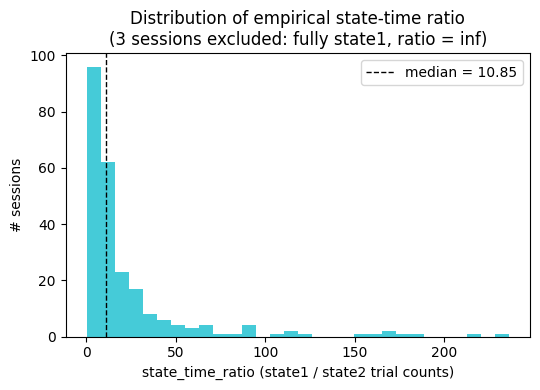


n = 241 sessions with finite ratio (3 excluded)
Pearson (lda_1 vs log(state_time_ratio)):  r = 0.095, p = 0.1406
Spearman (lda_1 vs state_time_ratio):      r = -0.013, p = 0.8410


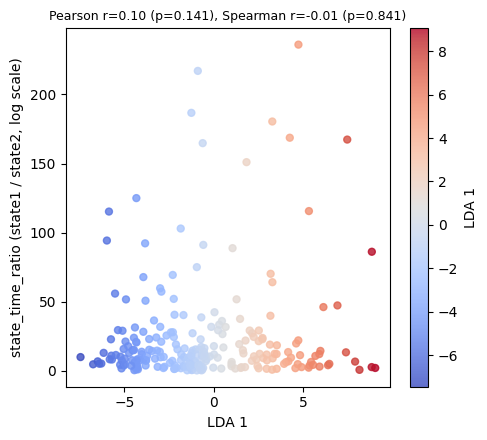

In [83]:
state_counts = states_df.groupby(['eid', 'dominant_state']).size().unstack(fill_value=0)
state_counts = state_counts.reindex(columns=['state1', 'state2'], fill_value=0).reset_index()
state_counts = state_counts.rename(columns={'eid': 'session', 'state1': 'n_state1', 'state2': 'n_state2'})

matched = matched.merge(state_counts[['session', 'n_state1', 'n_state2']], on='session', how='left')

# state1 kept as numerator; sessions fully in state1 (n_state2 == 0) give inf by construction,
# not a capped/fudged value, since "time in state1 relative to zero time in state2" is unbounded.
matched['state_time_ratio'] = matched['n_state1'] / matched['n_state2']

n_fully_state1 = np.isinf(matched['state_time_ratio']).sum()
print(f"Sessions fully in state1 (state_time_ratio = inf): {n_fully_state1} / {len(matched)}")
print(matched['state_time_ratio'].replace(np.inf, np.nan).describe())

fig, ax = plt.subplots(figsize=(5.5, 4))
finite_ratio = matched['state_time_ratio'].replace(np.inf, np.nan).dropna()
ax.hist(finite_ratio, bins=30, color='tab:cyan', alpha=0.8)
ax.axvline(finite_ratio.median(), color='k', linestyle='--', linewidth=1,
           label=f"median = {finite_ratio.median():.2f}")
ax.set_xlabel('state_time_ratio (state1 / state2 trial counts)')
ax.set_ylabel('# sessions')
ax.set_title(f'Distribution of empirical state-time ratio\n({n_fully_state1} sessions excluded: fully state1, ratio = inf)')
ax.legend()
plt.tight_layout()
plt.show()

# correlation with LDA 1, on the finite subset (log-space, same rationale as state_ratio above)
finite_mask = np.isfinite(matched['state_time_ratio'])
log_time_ratio = np.log(matched.loc[finite_mask, 'state_time_ratio'])
log_time_ratio = matched.loc[finite_mask, 'state_time_ratio']

lda1_finite = matched.loc[finite_mask, 'lda_1']

r_pearson, p_pearson = pearsonr(lda1_finite, log_time_ratio)
r_spearman, p_spearman = spearmanr(lda1_finite, matched.loc[finite_mask, 'state_time_ratio'])
print(f"\nn = {finite_mask.sum()} sessions with finite ratio ({(~finite_mask).sum()} excluded)")
print(f"Pearson (lda_1 vs log(state_time_ratio)):  r = {r_pearson:.3f}, p = {p_pearson:.4f}")
print(f"Spearman (lda_1 vs state_time_ratio):      r = {r_spearman:.3f}, p = {p_spearman:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(lda1_finite, matched.loc[finite_mask, 'state_time_ratio'], c=lda1_finite,
                 cmap='coolwarm', alpha=0.8, s=25)
# ax.set_yscale('log')

a, b = np.polyfit(lda1_finite, log_time_ratio, 1)
x_range = np.linspace(lda1_finite.min(), lda1_finite.max(), 100)
# ax.plot(x_range, np.exp(a * x_range + b), color='k', linewidth=1.5)

ax.set_xlabel('LDA 1')
ax.set_ylabel('state_time_ratio (state1 / state2, log scale)')
ax.set_title(f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), Spearman r={r_spearman:.2f} (p={p_spearman:.3f})",
             fontsize=9)
fig.colorbar(sc, ax=ax, label='LDA 1')
plt.tight_layout()
plt.show()

# Why state_ratio and state_time_ratio disagree on LDA 1

`state_ratio` (soft, `mean_p_state2/mean_p_state1`) correlates with LDA 1; `state_time_ratio` (hard, dominant-state trial counts) does not. This is not a bug - it comes from hard-thresholding the GLM-HMM posterior at p=0.5, which discards graded uncertainty that carries the LDA 1 signal.

Fraction of ALL trials with p_state1 in (0.05, 0.95) i.e. not near-certain: 0.500

LDA 1 vs (soft - hard) occupancy gap:  r = -0.391, p = 2.42e-10
LDA 1 vs fraction of ambiguous trials: r = -0.154, p = 0.016


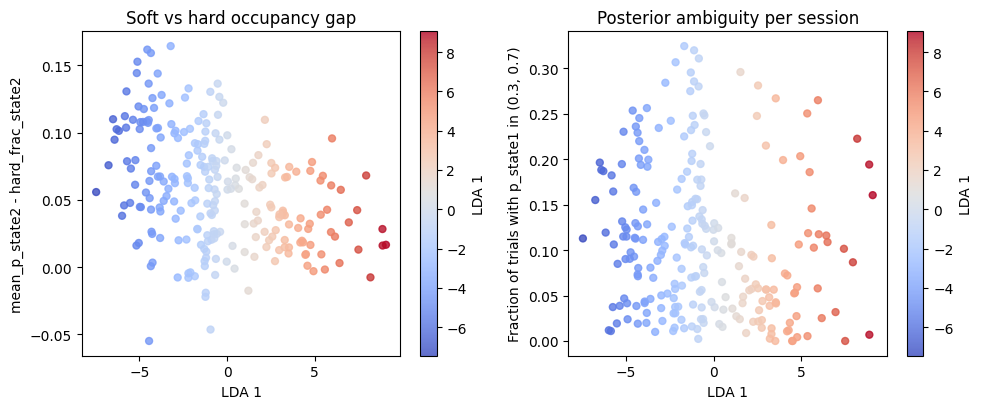

In [84]:
states_df['ambiguous'] = (states_df['p_state1'] > 0.3) & (states_df['p_state1'] < 0.7)
frac_ambiguous = states_df.groupby('eid')['ambiguous'].mean().rename('frac_ambiguous')
hard_frac_state2 = (states_df.groupby('eid')['dominant_state'].apply(lambda s: (s == 'state2').mean())
                    .rename('hard_frac_state2'))

matched = matched.merge(frac_ambiguous, left_on='session', right_index=True, how='left')
matched = matched.merge(hard_frac_state2, left_on='session', right_index=True, how='left')
matched['soft_minus_hard'] = matched['mean_p_state2'] - matched['hard_frac_state2']

print(f"Fraction of ALL trials with p_state1 in (0.05, 0.95) i.e. not near-certain: "
      f"{((states_df['p_state1'] > 0.05) & (states_df['p_state1'] < 0.95)).mean():.3f}")
print()

r, p = pearsonr(matched['lda_1'], matched['soft_minus_hard'])
print(f"LDA 1 vs (soft - hard) occupancy gap:  r = {r:.3f}, p = {p:.2e}")
r, p = pearsonr(matched['lda_1'], matched['frac_ambiguous'])
print(f"LDA 1 vs fraction of ambiguous trials: r = {r:.3f}, p = {p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

sc = axes[0].scatter(matched['lda_1'], matched['soft_minus_hard'], c=matched['lda_1'], cmap='coolwarm', s=25, alpha=0.8)
axes[0].set_xlabel('LDA 1')
axes[0].set_ylabel('mean_p_state2 - hard_frac_state2')
axes[0].set_title('Soft vs hard occupancy gap')
fig.colorbar(sc, ax=axes[0], label='LDA 1')

sc2 = axes[1].scatter(matched['lda_1'], matched['frac_ambiguous'], c=matched['lda_1'], cmap='coolwarm', s=25, alpha=0.8)
axes[1].set_xlabel('LDA 1')
axes[1].set_ylabel('Fraction of trials with p_state1 in (0.3, 0.7)')
axes[1].set_title('Posterior ambiguity per session')
fig.colorbar(sc2, ax=axes[1], label='LDA 1')

plt.tight_layout()
plt.show()

## Is the soft-hard gap just a trial-count / session-length artifact?

Ruling out the alternative explanation that lower-LDA-1 sessions simply have less data (noisier GLM-HMM posteriors) rather than a genuine behavioral difference. Session duration comes from `goCueTrigger_times` in `4_mice/session_trial_meta_03-07-2026` (first-to-last trial span), so no extra ONE fetch is needed.

In [85]:
trials_meta = pd.read_parquet(prefix + '4_mice/session_trial_meta_03-07-2026')
session_duration = (trials_meta.groupby('session')['goCueTrigger_times'].agg(lambda x: x.max() - x.min())
                     .rename('session_duration'))
matched = matched.merge(session_duration, left_on='session', right_index=True, how='left')

r, p = pearsonr(matched['soft_minus_hard'], matched['n_trials'])
print(f"gap vs n_trials:                        r = {r:.3f}, p = {p:.4f}")
r, p = pearsonr(matched['lda_1'], matched['n_trials'])
print(f"LDA 1 vs n_trials:                       r = {r:.3f}, p = {p:.4f}")

dur_valid = matched.dropna(subset=['session_duration'])
r, p = pearsonr(dur_valid['soft_minus_hard'], dur_valid['session_duration'])
print(f"gap vs session_duration (n={len(dur_valid)}):          r = {r:.3f}, p = {p:.4f}")
r, p = pearsonr(dur_valid['lda_1'], dur_valid['session_duration'])
print(f"LDA 1 vs session_duration:               r = {r:.3f}, p = {p:.4f}")


def residualize(y, x):
    a, b = np.polyfit(x, y, 1)
    return y - (a * x + b)


gap_resid = residualize(matched['soft_minus_hard'], matched['n_trials'])
lda1_resid = residualize(matched['lda_1'], matched['n_trials'])
r, p = pearsonr(lda1_resid, gap_resid)
print(f"\nLDA 1 vs gap, partialling out n_trials: r = {r:.3f}, p = {p:.2e}  "
      f"(raw was r = {pearsonr(matched['lda_1'], matched['soft_minus_hard'])[0]:.3f})"
)

gap vs n_trials:                        r = 0.158, p = 0.0138
LDA 1 vs n_trials:                       r = -0.122, p = 0.0572
gap vs session_duration (n=243):          r = 0.091, p = 0.1594
LDA 1 vs session_duration:               r = -0.040, p = 0.5309

LDA 1 vs gap, partialling out n_trials: r = -0.379, p = 8.93e-10  (raw was r = -0.391)
